# Исследование методов оптимизации

Лабораторная работа по курсу «Продвинутые методы оптимизации».

Исследуем:
- Методы 0-го порядка (Нелдер-Мид)
- Методы 1-го порядка (градиентный спуск)
- Методы 2-го порядка (Ньютон)

На трёх целевых функциях с использованием конструктивных чисел.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import time

from src.ConstructiveNumber import ConstructiveNumber as CN
from src.BlackBox import QuadraticGoodCond, QuadraticBadCond, Rosenbrock
from src.Optimizers import gradient_descent, nelder_mead, newton_method

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

functions = [
    QuadraticGoodCond(),
    QuadraticBadCond(),
    Rosenbrock()
]

print('Функции загружены:')
for f in functions:
    print(f'  {f.name}, dim={f.dim}, x* = {np.round(f.minimum, 4)}')

Функции загружены:
  Квадратичная 6D (cond ≈ 1.16), dim=6, x* = [-1.0284  0.4951 -0.2807  0.2101 -0.1367  0.3894]
  Квадратичная 4D (cond ≈ 100), dim=4, x* = [ 0.2901  0.2155 -0.3377 -0.3972]
  Розенброк 3D, dim=3, x* = [1. 1. 1.]


## 1. Подбор learning rate для градиентного спуска

Для каждой функции протестируем несколько значений lr и выберем оптимальный.

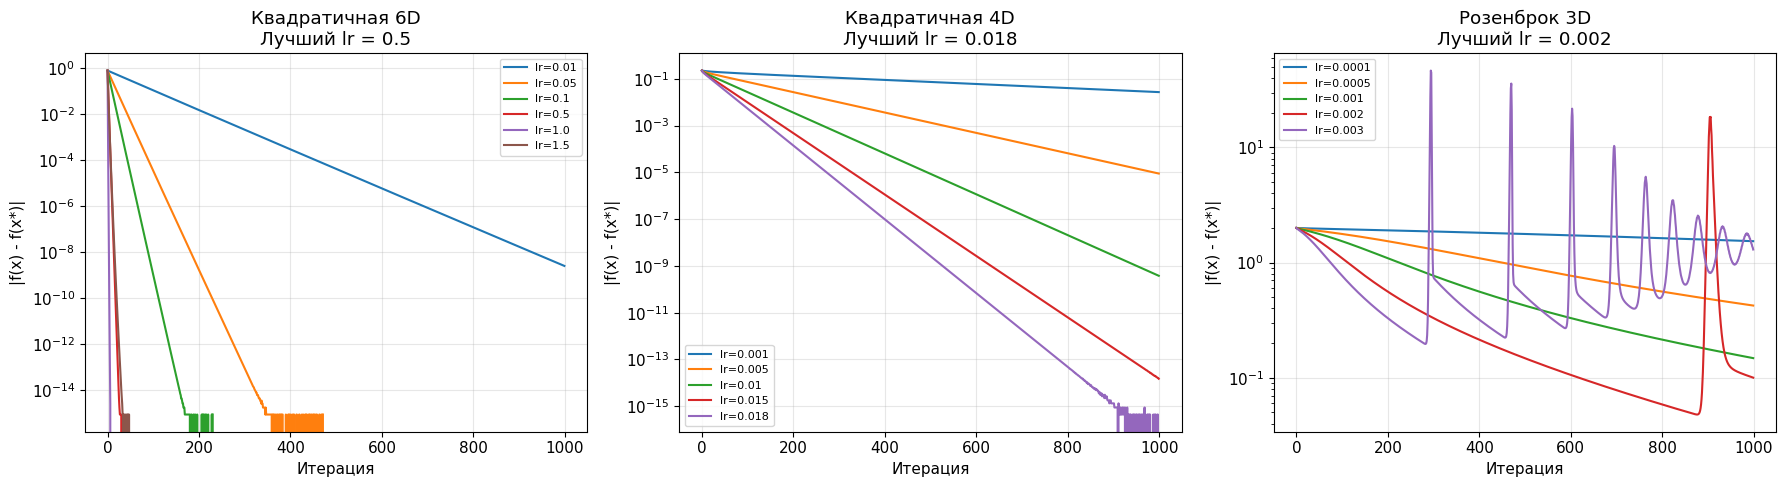

Выбранные lr: {'Квадратичная 6D': 0.5, 'Квадратичная 4D': 0.018, 'Розенброк 3D': 0.002}


In [2]:
lr_candidates = {
    'Квадратичная 6D': [0.01, 0.05, 0.1, 0.5, 1.0, 1.5],
    'Квадратичная 4D': [0.001, 0.005, 0.01, 0.015, 0.018],
    'Розенброк 3D': [0.0001, 0.0005, 0.001, 0.002, 0.003]
}

best_lrs = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, func_obj in enumerate(functions):
    short_name = ['Квадратичная 6D', 'Квадратичная 4D', 'Розенброк 3D'][idx]
    x0 = np.zeros(func_obj.dim)
    ax = axes[idx]
    
    best_lr = None
    best_final_f = float('inf')
    
    for lr in lr_candidates[short_name]:
        func_obj.reset_counters()
        try:
            x_res, hist = gradient_descent(func_obj, x0, lr=lr, max_iter=1000, tol=1e-10)
            final_f = hist['f'][-1]
            if not np.isnan(final_f) and not np.isinf(final_f):
                ax.semilogy(np.abs(np.array(hist['f']) - func_obj.func(func_obj.minimum)),
                           label=f'lr={lr}')
                if final_f < best_final_f:
                    best_final_f = final_f
                    best_lr = lr
        except:
            pass
    
    best_lrs[short_name] = best_lr
    ax.set_title(f'{short_name}\nЛучший lr = {best_lr}')
    ax.set_xlabel('Итерация')
    ax.set_ylabel('|f(x) - f(x*)|')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/lr_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Выбранные lr: {best_lrs}')

## 2. Сравнение методов оптимизации

Запускаем все три метода на всех трёх функциях и собираем статистику.

In [3]:
results = {}

configs = [
    ('Квадратичная 6D', functions[0], np.zeros(6)),
    ('Квадратичная 4D', functions[1], np.zeros(4)),
    ('Розенброк 3D', functions[2], np.array([-1.0, -1.0, -1.0]))
]

for fname, func_obj, x0 in configs:
    results[fname] = {}
    lr = best_lrs[fname]
    
    # Градиентный спуск
    func_obj.reset_counters()
    x_gd, h_gd = gradient_descent(func_obj, x0, lr=lr, max_iter=5000, tol=1e-10)
    results[fname]['GD'] = {
        'x': x_gd, 'history': h_gd,
        'f_calls': func_obj.func_calls, 'g_calls': func_obj.grad_calls,
        'error': np.linalg.norm(x_gd - func_obj.minimum),
        'iters': len(h_gd['f']),
        'time': h_gd['time'][-1] if h_gd['time'] else 0
    }
    
    # Нелдер-Мид
    func_obj.reset_counters()
    x_nm, h_nm = nelder_mead(func_obj, x0, max_iter=5000, tol=1e-12)
    results[fname]['NM'] = {
        'x': x_nm, 'history': h_nm,
        'f_calls': func_obj.func_calls, 'g_calls': 0,
        'error': np.linalg.norm(x_nm - func_obj.minimum),
        'iters': len(h_nm['f']),
        'time': h_nm['time'][-1] if h_nm['time'] else 0
    }
    
    # Ньютон
    func_obj.reset_counters()
    x_nt, h_nt = newton_method(func_obj, x0, max_iter=200, tol=1e-10)
    results[fname]['Newton'] = {
        'x': x_nt, 'history': h_nt,
        'f_calls': func_obj.func_calls, 'g_calls': func_obj.grad_calls,
        'h_calls': func_obj.hess_calls,
        'error': np.linalg.norm(x_nt - func_obj.minimum),
        'iters': len(h_nt['f']),
        'time': h_nt['time'][-1] if h_nt['time'] else 0
    }

# Таблица результатов
print(f'{"Функция":<20} {"Метод":<10} {"Итер":<8} {"f_calls":<10} {"g_calls":<10} {"||x-x*||":<12} {"Время, с":<10}')
print('-' * 82)
for fname in results:
    for method in results[fname]:
        r = results[fname][method]
        print(f'{fname:<20} {method:<10} {r["iters"]:<8} {r["f_calls"]:<10} {r["g_calls"]:<10} {r["error"]:<12.2e} {r["time"]:<10.4f}')

Функция              Метод      Итер     f_calls    g_calls    ||x-x*||     Время, с  
----------------------------------------------------------------------------------
Квадратичная 6D      GD         37       37         37         7.53e-11     0.0006    
Квадратичная 6D      NM         210      564        0          1.73e-06     0.0060    
Квадратичная 6D      Newton     2        2          2          0.00e+00     0.0001    
Квадратичная 4D      GD         1244     1244       1244       9.89e-11     0.0099    
Квадратичная 4D      NM         135      378        0          3.51e-07     0.0032    
Квадратичная 4D      Newton     2        2          2          0.00e+00     0.0000    
Розенброк 3D         GD         5000     5000       5000       5.71e-01     0.0335    
Розенброк 3D         NM         144      395        0          1.26e-06     0.0030    
Розенброк 3D         Newton     15       15         15         4.37e-11     0.0003    


## 3. Графики сходимости

Сравним скорость сходимости методов по итерациям.

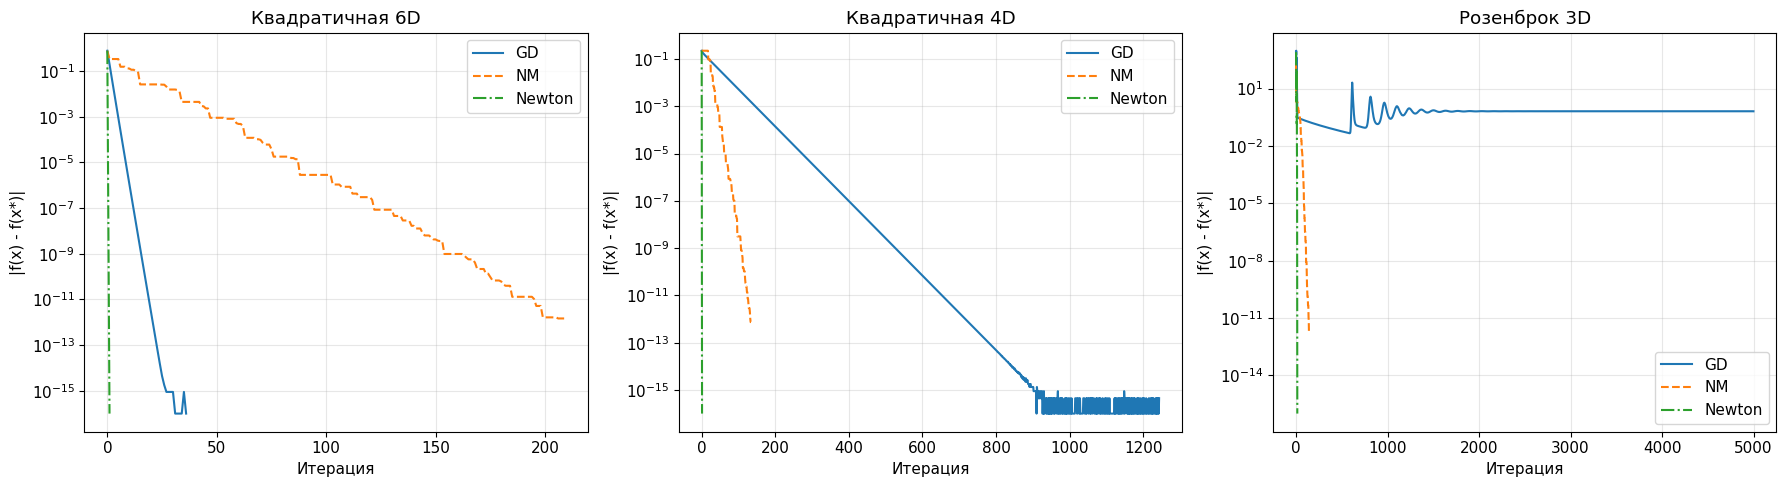

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (fname, func_obj, x0) in enumerate(configs):
    ax = axes[idx]
    f_star = func_obj.func(func_obj.minimum)
    
    for method, style in [('GD', '-'), ('NM', '--'), ('Newton', '-.')]: 
        h = results[fname][method]['history']
        vals = np.abs(np.array(h['f']) - f_star)
        vals = np.maximum(vals, 1e-16)  # для логарифмического графика
        ax.semilogy(vals, style, label=method, linewidth=1.5)
    
    ax.set_title(fname)
    ax.set_xlabel('Итерация')
    ax.set_ylabel('|f(x) - f(x*)|')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Траектории спуска по линиям уровня

Проецируем траекторию на 2D-плоскость (первые две координаты, остальные фиксированы в x*).

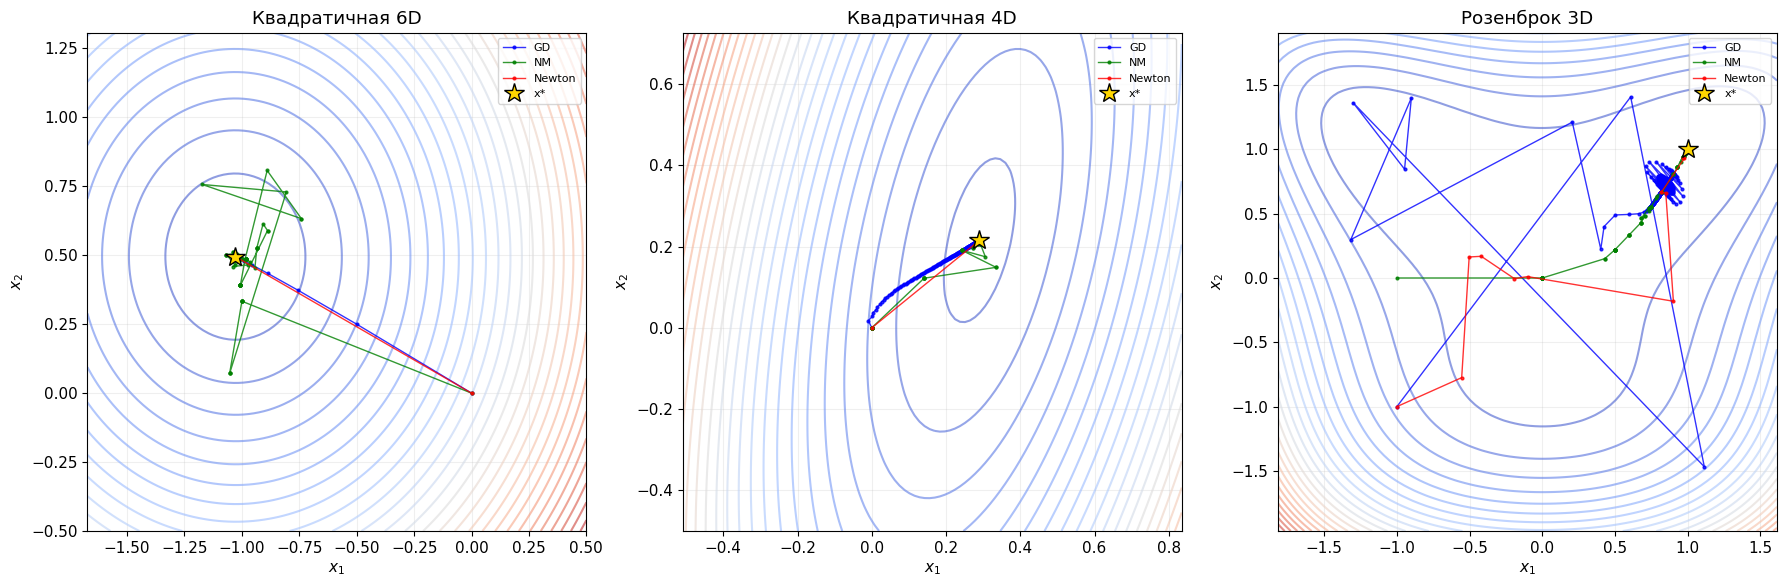

In [ ]:
def plot_contour_trajectory(func_obj, results_dict, fname, ax, coord_i=0, coord_j=1):
    """Построить линии уровня и траектории на 2D-сечении."""
    x_star = func_obj.minimum
    
    # Собрать все точки траекторий для определения границ
    all_pts = []
    for method in results_dict:
        pts = np.array(results_dict[method]['history']['x'])
        all_pts.append(pts[:, [coord_i, coord_j]])
    all_pts = np.vstack(all_pts)
    
    margin = 0.5
    xi_min = min(all_pts[:, 0].min(), x_star[coord_i]) - margin
    xi_max = max(all_pts[:, 0].max(), x_star[coord_i]) + margin
    xj_min = min(all_pts[:, 1].min(), x_star[coord_j]) - margin
    xj_max = max(all_pts[:, 1].max(), x_star[coord_j]) + margin
    
    xi_grid = np.linspace(xi_min, xi_max, 100)
    xj_grid = np.linspace(xj_min, xj_max, 100)
    XI, XJ = np.meshgrid(xi_grid, xj_grid)4
    
    Z = np.zeros_like(XI)
    for ii in range(XI.shape[0]):
        for jj in range(XI.shape[1]):
            x_eval = x_star.copy()
            x_eval[coord_i] = XI[ii, jj]
            x_eval[coord_j] = XJ[ii, jj]
            func_obj._func_calls -= 1  # не считаем эти вызовы
            Z[ii, jj] = func_obj.func(x_eval)
    
    ax.contour(XI, XJ, Z, levels=30, cmap='coolwarm', alpha=0.6)
    
    colors = {'GD': 'blue', 'NM': 'green', 'Newton': 'red'}
    for method in results_dict:
        pts = np.array(results_dict[method]['history']['x'])
        ax.plot(pts[:, coord_i], pts[:, coord_j], '-o', color=colors[method],
                markersize=2, linewidth=1, label=method, alpha=0.8)
    
    ax.plot(*x_star[[coord_i, coord_j]], '*', color='gold', markersize=15,
            markeredgecolor='black', label='x*', zorder=5)
    ax.set_xlabel(f'$x_{{{coord_i+1}}}$')
    ax.set_ylabel(f'$x_{{{coord_j+1}}}$')
    ax.set_title(fname)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (fname, func_obj, x0) in enumerate(configs):
    plot_contour_trajectory(func_obj, results[fname], fname, axes[idx])

plt.tight_layout()
plt.savefig('img/trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Исследование динамики ε при использовании конструктивных чисел

Запускаем оптимизацию с конструктивными числами трёх разных порядков ε и отслеживаем, как ε растёт в процессе итераций.

In [6]:
epsilons = [1e-2, 1e-5, 1e-8]
cn_results = {}

for fname, func_obj, x0 in configs:
    cn_results[fname] = {}
    lr = best_lrs[fname]
    
    for eps in epsilons:
        cn_results[fname][eps] = {}
        
        # Градиентный спуск с CN
        func_obj.reset_counters()
        x_gd, h_gd = gradient_descent(func_obj, x0, lr=lr, max_iter=500,
                                       tol=1e-10, use_cn=True, cn_epsilon=eps)
        cn_results[fname][eps]['GD'] = h_gd
        
        # Ньютон с CN
        func_obj.reset_counters()
        x_nt, h_nt = newton_method(func_obj, x0, max_iter=50,
                                    tol=1e-10, use_cn=True, cn_epsilon=eps)
        cn_results[fname][eps]['Newton'] = h_nt
        
        # Нелдер-Мид с CN (отслеживание ε значения функции)
        func_obj.reset_counters()
        x_nm, h_nm = nelder_mead(func_obj, x0, max_iter=500,
                                  tol=1e-10, use_cn=True, cn_epsilon=eps)
        cn_results[fname][eps]['NM'] = h_nm

print('Вычисления с CN завершены.')

Вычисления с CN завершены.


/opt/homebrew/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


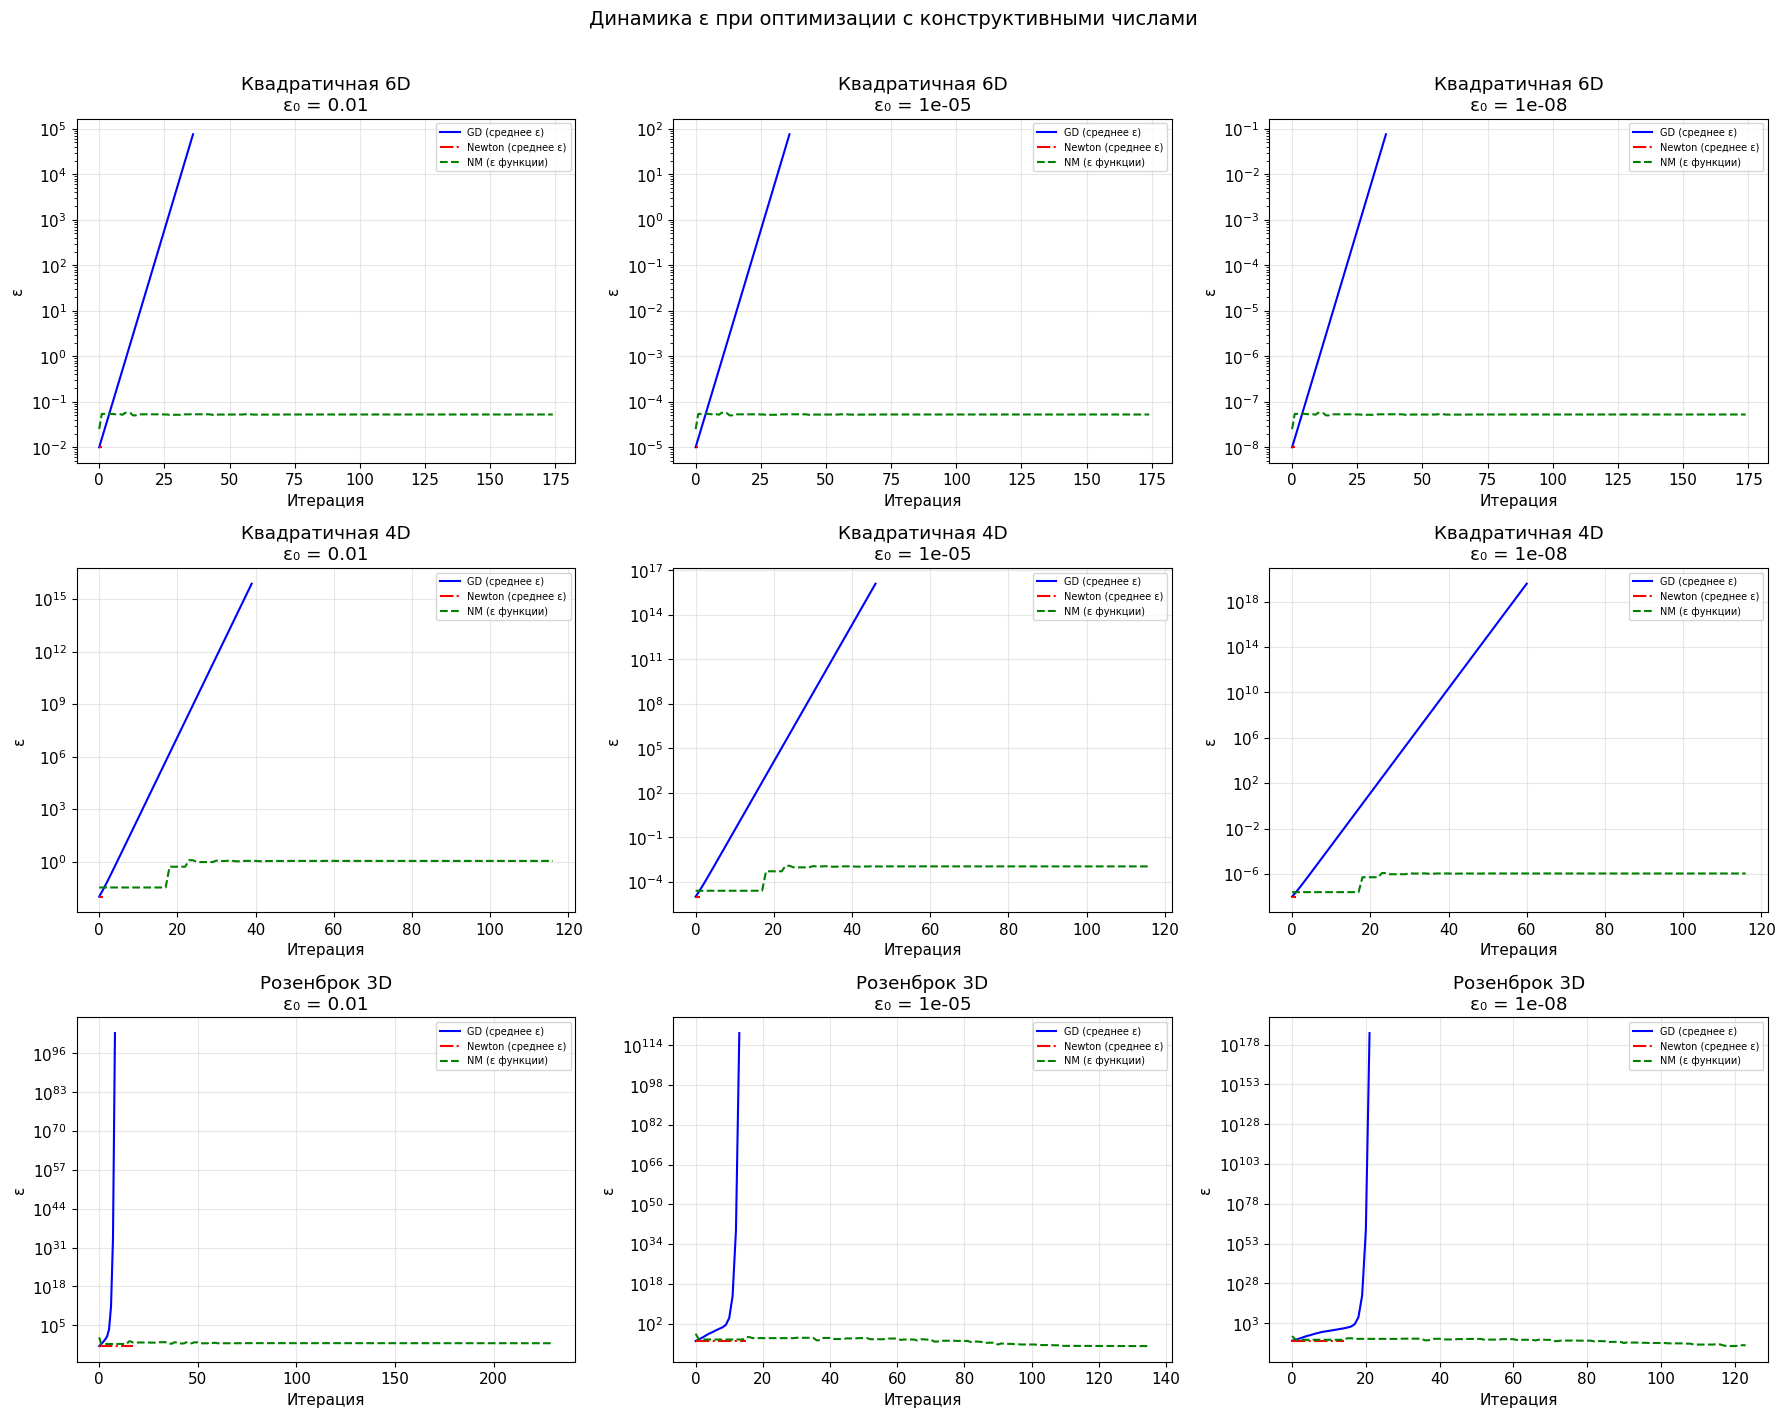

In [7]:
# Графики динамики epsilon для GD и Newton (средний epsilon по всем координатам)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, (fname, func_obj, x0) in enumerate(configs):
    for col, eps in enumerate(epsilons):
        ax = axes[row][col]
        
        # GD epsilon
        h_gd = cn_results[fname][eps]['GD']
        if h_gd['epsilon']:
            eps_gd = [np.mean(e) for e in h_gd['epsilon']]
            ax.semilogy(eps_gd, '-', label='GD (среднее ε)', color='blue')
        
        # Newton epsilon
        h_nt = cn_results[fname][eps]['Newton']
        if h_nt['epsilon']:
            eps_nt = [np.mean(e) for e in h_nt['epsilon']]
            ax.semilogy(eps_nt, '-.', label='Newton (среднее ε)', color='red')
        
        # NM epsilon (функции)
        h_nm = cn_results[fname][eps]['NM']
        if h_nm['epsilon'] and any(e > 0 for e in h_nm['epsilon']):
            ax.semilogy(h_nm['epsilon'], '--', label='NM (ε функции)', color='green')
        
        ax.set_title(f'{fname}\nε₀ = {eps}')
        ax.set_xlabel('Итерация')
        ax.set_ylabel('ε')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle('Динамика ε при оптимизации с конструктивными числами', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('img/epsilon_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

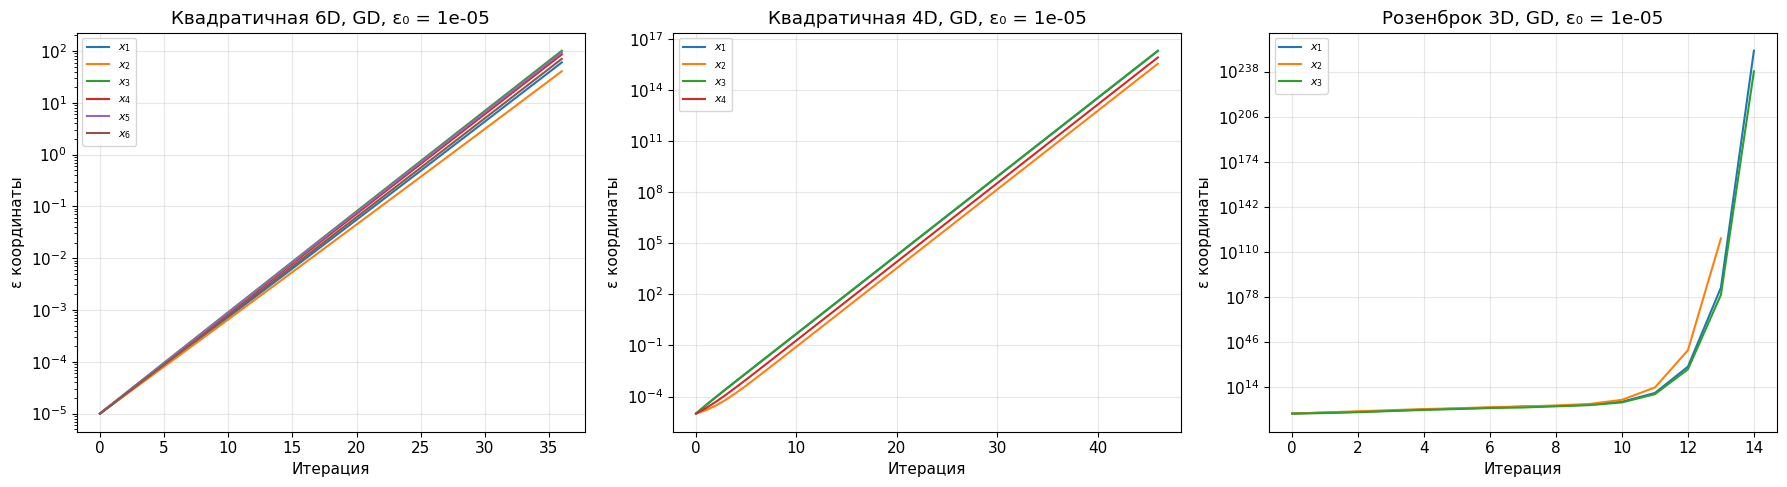

In [8]:
# Покомпонентная динамика epsilon для GD (подробно на примере одной функции и одного eps)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (fname, func_obj, x0) in enumerate(configs):
    ax = axes[idx]
    eps = 1e-5
    h_gd = cn_results[fname][eps]['GD']
    
    if h_gd['epsilon']:
        eps_arr = np.array(h_gd['epsilon'])
        for dim_i in range(min(eps_arr.shape[1], 6)):
            ax.semilogy(eps_arr[:, dim_i], label=f'$x_{{{dim_i+1}}}$')
    
    ax.set_title(f'{fname}, GD, ε₀ = {eps}')
    ax.set_xlabel('Итерация')
    ax.set_ylabel('ε координаты')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/epsilon_per_component.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Сравнение финального ε на разных функциях и методах

In [9]:
print(f'{"Функция":<20} {"Метод":<10} {"ε₀":<12} {"Финальный ср. ε":<20} {"Рост ε":<15}')
print('-' * 80)

for fname, func_obj, x0 in configs:
    for method in ['GD', 'Newton']:
        for eps in epsilons:
            h = cn_results[fname][eps][method]
            if h['epsilon']:
                final_eps = np.mean(h['epsilon'][-1])
                growth = final_eps / eps if eps > 0 else 0
                print(f'{fname:<20} {method:<10} {eps:<12.0e} {final_eps:<20.6e} {growth:<15.1f}x')

Функция              Метод      ε₀           Финальный ср. ε      Рост ε         
--------------------------------------------------------------------------------
Квадратичная 6D      GD         1e-02        7.555141e+04         7555141.4      x
Квадратичная 6D      GD         1e-05        7.555141e+01         7555141.4      x
Квадратичная 6D      GD         1e-08        7.555141e-02         7555141.4      x
Квадратичная 6D      Newton     1e-02        1.000000e-02         1.0            x
Квадратичная 6D      Newton     1e-05        1.000000e-05         1.0            x
Квадратичная 6D      Newton     1e-08        1.000000e-08         1.0            x
Квадратичная 4D      GD         1e-02        7.559155e+15         755915543438530048.0x
Квадратичная 4D      GD         1e-05        1.284850e+16         1284850463215235366912.0x
Квадратичная 4D      GD         1e-08        3.712028e+19         3712027672525039254718382080.0x
Квадратичная 4D      Newton     1e-02        1.000000e-02    

## 7. Сравнение сходимости по времени

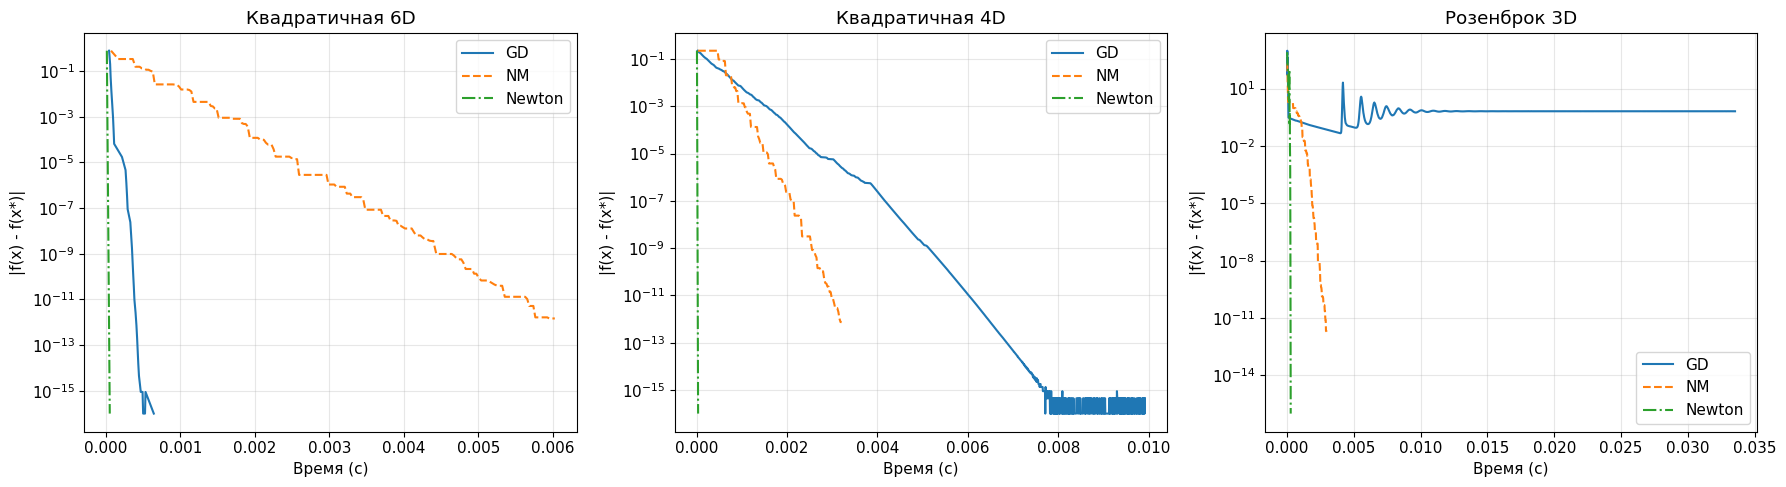

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (fname, func_obj, x0) in enumerate(configs):
    ax = axes[idx]
    f_star = func_obj.func(func_obj.minimum)
    
    for method, style in [('GD', '-'), ('NM', '--'), ('Newton', '-.')]:
        h = results[fname][method]['history']
        vals = np.abs(np.array(h['f']) - f_star)
        vals = np.maximum(vals, 1e-16)
        ax.semilogy(h['time'], vals, style, label=method, linewidth=1.5)
    
    ax.set_title(fname)
    ax.set_xlabel('Время (с)')
    ax.set_ylabel('|f(x) - f(x*)|')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/convergence_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Норма градиента по итерациям (GD и Newton)

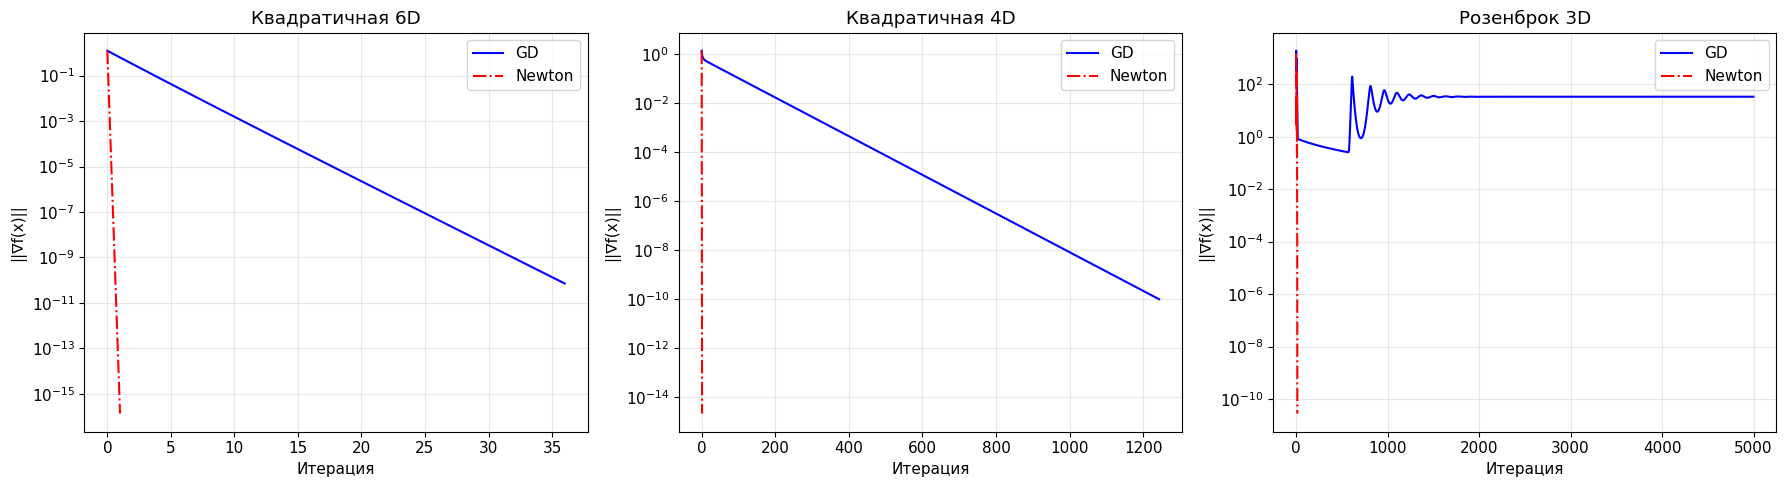

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (fname, func_obj, x0) in enumerate(configs):
    ax = axes[idx]
    
    for method, style, color in [('GD', '-', 'blue'), ('Newton', '-.', 'red')]:
        h = results[fname][method]['history']
        gn = np.array(h['grad_norm'])
        gn = np.maximum(gn, 1e-16)
        ax.semilogy(gn, style, label=method, color=color, linewidth=1.5)
    
    ax.set_title(fname)
    ax.set_xlabel('Итерация')
    ax.set_ylabel('||∇f(x)||')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/grad_norm.png', dpi=150, bbox_inches='tight')
plt.show()

## Выводы

### По методам оптимизации

1. **Метод Ньютона** (2-го порядка) — наиболее эффективен. На квадратичных функциях сходится за 1 итерацию (точное решение), на Розенброке демонстрирует квадратичную скорость сходимости вблизи минимума.

2. **Градиентный спуск** (1-го порядка) — скорость сходимости сильно зависит от числа обусловленности. На хорошо обусловленной функции сходится быстро, на плохо обусловленной — значительно медленнее. Критически важен выбор learning rate.

3. **Нелдер-Мид** (0-го порядка) — не требует производных, но сходится медленнее. Особенно заметна разница в высокоразмерных задачах. Однако не чувствителен к числу обусловленности.

### По динамике ε конструктивных чисел

1. ε растёт с каждой итерацией из-за интервальной арифметики — каждая операция расширяет интервал.

2. На плохо обусловленных задачах ε растёт быстрее из-за больших коэффициентов матрицы.

3. Методы, требующие меньше итераций (Ньютон), накапливают меньшую погрешность ε.

4. Начальный порядок ε₀ масштабирует финальный ε, но относительный рост (ε_final/ε₀) практически одинаков для разных ε₀.